# Habitable Zone Classification — Logistic Regression



In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


In [3]:
from xgboost import XGBClassifier
import shap
import seaborn as sns

## 1. Load data

In [44]:
df_cleaned = pd.read_csv("exoplanet_clean.csv")
df = df_cleaned.copy()

print("Shape:", df.shape)
df.head()

Shape: (5451, 21)


,n_stars,n_planets,discovery_method,orbital_period_days,planet_radius_earth,planet_mass_earth,semi_major_axis_au,star_temp_k,star_radius_sun,star_mass_sun,...,star_metallicity,dist_from_earth_pc,star_vmag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,1,1,Transit,1.003934,1.710000,3.570,0.01750,4971.0,0.750,0.790,...,-0.05,820.905,16.0470,Super-Earth,False,False,False,Far(500-2kpc),K-type,Short(1-10d)
1,1,1,Transit,8.172400,3.323214,11.000,0.07790,5705.0,0.905,0.943,...,-0.06,1061.770,15.4540,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
2,1,1,Transit,6.283855,0.800000,0.437,0.06865,6022.0,1.230,1.120,...,0.07,493.175,12.4420,Sub-Earth,False,False,False,Mid(100-500pc),F-type,Short(1-10d)
3,1,1,Transit,3.173917,3.150000,10.100,0.04641,6747.0,1.810,1.490,...,0.08,1318.050,14.0310,Mini-Neptune,False,False,False,Far(500-2kpc),F-type,Short(1-10d)
4,1,1,Transit,56.358501,4.540605,18.700,0.26980,5446.0,0.821,0.824,...,-0.20,962.888,16.0249,Neptune-like,False,False,True,Far(500-2kpc),G-type(Sun-like),Medium(10-100d)


In [5]:
df.dtypes

n_stars                   int64
n_planets                 int64
discovery_method         object
orbital_period_days     float64
planet_radius_earth     float64
planet_mass_earth       float64
semi_major_axis_au      float64
star_temp_k             float64
star_radius_sun         float64
star_mass_sun           float64
star_surface_gravity    float64
star_metallicity        float64
dist_from_earth_pc      float64
star_vmag               float64
planet_type              object
habitable_zone_flag        bool
multi_planet_system        bool
is_recent_discovery        bool
dist_category            object
star_type                object
orbital_period_cat       object
dtype: object

## 2. Feature engineering
Note: `stellar_flux` is treated as a simplified proxy rather than a fully physical luminosity model.

In [45]:
# Simplified stellar flux proxy
df["stellar_flux"] = (df["star_temp_k"] ** 4) / (df["semi_major_axis_au"] ** 2)
df["log_stellar_flux"] = np.log(df["stellar_flux"] + 1e-6) #
# df.drop(columns=["stellar_flux"], inplace=True) # Log transformations

df["log_semi_major_axis"] = np.log(df["semi_major_axis_au"] + 1e-6)
df["log_star_temp"] = np.log(df["star_temp_k"])

# Interaction term
df["temp_distance_interaction"] = df["star_temp_k"] * df["semi_major_axis_au"]

# Binary flags
df["habitable_zone_flag"] = df["habitable_zone_flag"].astype(int)
df["multi_planet_system"] = df["multi_planet_system"].astype(int)

In [98]:
df.columns

Index(['n_stars', 'n_planets', 'discovery_method', 'orbital_period_days',
       'planet_radius_earth', 'planet_mass_earth', 'semi_major_axis_au',
       'star_temp_k', 'star_radius_sun', 'star_mass_sun',
       'star_surface_gravity', 'star_metallicity', 'dist_from_earth_pc',
       'star_vmag', 'planet_type', 'habitable_zone_flag',
       'multi_planet_system', 'is_recent_discovery', 'dist_category',
       'star_type', 'orbital_period_cat', 'stellar_flux', 'log_stellar_flux',
       'log_semi_major_axis', 'log_star_temp', 'temp_distance_interaction'],
      dtype='object')

In [74]:
features = [
    "semi_major_axis_au",
    "orbital_period_days",
    "star_temp_k",
    "star_radius_sun",
    "star_mass_sun",
    "star_metallicity",
    "planet_mass_earth",
    "planet_radius_earth",

    "multi_planet_system",
    "log_stellar_flux",
    "log_semi_major_axis",
    "log_star_temp",
    "temp_distance_interaction"
]

target = "habitable_zone_flag"

df_model = df[features + [target]].dropna().copy()
X = df_model[features]
y = df_model[target]

print("Model data shape:", df_model.shape)
print("\nClass distribution:")
print(y.value_counts(normalize=True).rename("proportion"))

Model data shape: (5451, 14)

Class distribution:
habitable_zone_flag
0    0.927903
1    0.072097
Name: proportion, dtype: float64


## 3. Train / validation / test split

In [75]:
# First split: hold out final test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Second split: split remaining data into train and validation
# 0.25 of 80% = 20%, so final ratio is 60/20/20
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=42
)
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nTrain class balance:")
print(y_train.value_counts())
print("\nValidation class balance:")
print(y_val.value_counts())
print("\nTest class balance:")
print(y_test.value_counts())

Train shape: (3270, 13)
Validation shape: (1090, 13)
Test shape: (1091, 13)

Train class balance:
habitable_zone_flag
0    3034
1     236
Name: count, dtype: int64

Validation class balance:
habitable_zone_flag
0    1012
1      78
Name: count, dtype: int64

Test class balance:
habitable_zone_flag
0    1012
1      79
Name: count, dtype: int64


## 4. Define functions

In [76]:
def evaluate_probabilities(y_true, y_prob, threshold=0.5, model_name="Model"):
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Habitable", "Habitable"]
    )
    disp.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
    axes[0].set_title(f"Confusion Matrix ({model_name})")

    axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    axes[1].plot([0, 1], [0, 1], linestyle="--")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"ROC Curve ({model_name})")
    axes[1].legend()

    axes[2].plot(recall_curve, precision_curve, label=f"AP = {pr_auc:.3f}")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")
    axes[2].set_title(f"Precision-Recall Curve ({model_name})")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    metrics = {
        "threshold": threshold,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }

    print(f"{model_name} metrics at threshold = {threshold:.3f}")
    for k, v in metrics.items():
        if k == "threshold":
            print(f"{k}: {v:.3f}")
        else:
            print(f"{k}: {v:.4f}")

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return metrics


def find_best_threshold(y_true, y_prob, n_grid=201):
    thresholds = np.linspace(0, 1, n_grid)

    rows = []
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        rows.append({
            "threshold": t,
            "precision": precision_score(y_true, y_pred_t, zero_division=0),
            "recall": recall_score(y_true, y_pred_t, zero_division=0),
            "f1": f1_score(y_true, y_pred_t, zero_division=0)
        })

    threshold_df = pd.DataFrame(rows)
    best_idx = threshold_df["f1"].idxmax()
    best_threshold = threshold_df.loc[best_idx, "threshold"]

    plt.figure(figsize=(8, 5))
    plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
    plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
    plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
    plt.axvline(best_threshold, linestyle="--", label=f"Best threshold = {best_threshold:.3f}")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Validation-set threshold tuning")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return best_threshold, threshold_df

## 5. Baseline logistic regression L2 Threshold = 0.5

In [77]:
ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]
model =  XGBClassifier(n_estimators=300, random_state=0,max_depth=5, learning_rate=0.1,eval_metric='logloss',early_stopping_rounds=10,scale_pos_weight=ratio)

model.fit(
    X_train, 
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
   # stop if no improvement after 10 rounds,
    verbose=10  # print training progress,
    
)
results = model.evals_result()

[0]	validation_0-logloss:0.61455	validation_1-logloss:0.61594
[10]	validation_0-logloss:0.26005	validation_1-logloss:0.27543
[20]	validation_0-logloss:0.15589	validation_1-logloss:0.18864
[30]	validation_0-logloss:0.11381	validation_1-logloss:0.16222
[40]	validation_0-logloss:0.09343	validation_1-logloss:0.14815
[50]	validation_0-logloss:0.08074	validation_1-logloss:0.14030
[60]	validation_0-logloss:0.06815	validation_1-logloss:0.13387
[70]	validation_0-logloss:0.05901	validation_1-logloss:0.12951
[80]	validation_0-logloss:0.05021	validation_1-logloss:0.12681
[90]	validation_0-logloss:0.04356	validation_1-logloss:0.12512
[100]	validation_0-logloss:0.03883	validation_1-logloss:0.12387
[110]	validation_0-logloss:0.03499	validation_1-logloss:0.12407
[114]	validation_0-logloss:0.03349	validation_1-logloss:0.12497


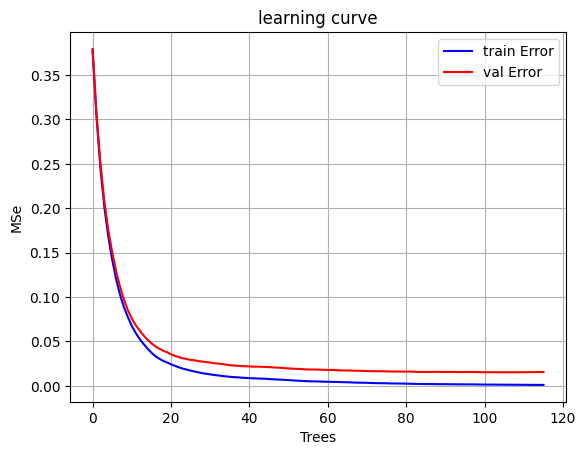

In [78]:
train_logloss = np.square(results['validation_0']['logloss'])
val_logloss = np.square(results['validation_1']['logloss'])


plt.plot(train_logloss, label='train Error', color='blue')
plt.plot(val_logloss, label='val Error', color='red')

plt.title('learning curve')
plt.xlabel('Trees')
plt.ylabel('MSe')
plt.legend()
plt.grid()
plt.show()

In [79]:

val_prob_baseline = model.predict_proba(X_val)[:, 1]
test_prob_baseline = model.predict_proba(X_test)[:, 1]

### Model 1 : Default Logistic regression(L2) result on the untouched test set

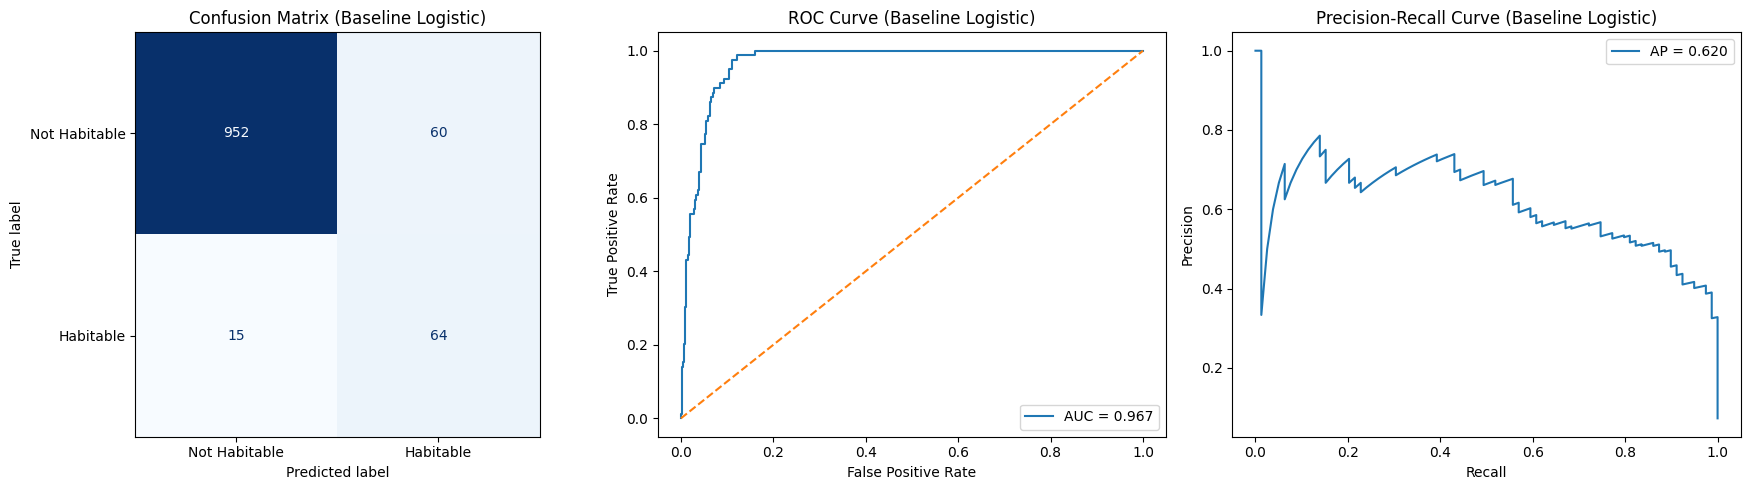

Baseline Logistic metrics at threshold = 0.500
threshold: 0.500
roc_auc: 0.9670
pr_auc: 0.6204
precision: 0.5161
recall: 0.8101
f1: 0.6305

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      1012
           1       0.52      0.81      0.63        79

    accuracy                           0.93      1091
   macro avg       0.75      0.88      0.80      1091
weighted avg       0.95      0.93      0.94      1091



In [80]:
baseline_metrics_05 = evaluate_probabilities(
    y_true=y_test,
    y_prob=test_prob_baseline,
    threshold=0.5,
    model_name="Baseline Logistic"
)

## 6. Hyperparameter tuning --> Model 2 L1 regularization C = 10

In [81]:
ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]


xgb_model = XGBClassifier(
    random_state=42,
    scale_pos_weight=ratio,
    eval_metric='logloss',
    n_estimators=200,   
    # early_stopping_rounds=10
)

param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0]
}

grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring={
        "roc_auc": "roc_auc",
        "average_precision": "average_precision"
    },
    refit="average_precision",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV average precision:", grid.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 7, 'subsample': 0.7}
Best CV average precision: 0.8156870483783019


In [82]:
model =  XGBClassifier(n_estimators=300, random_state=0,colsample_bytree= 0.7, learning_rate= 0.1, max_depth= 5, subsample= 0.7, eval_metric='logloss', early_stopping_rounds=10, scale_pos_weight=ratio)

model.fit(
    X_train, 
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
   # stop if no improvement after 10 rounds,
    verbose=10  # print training progress,
    
)
results = model.evals_result()

[0]	validation_0-logloss:0.61490	validation_1-logloss:0.61667


[10]	validation_0-logloss:0.26883	validation_1-logloss:0.28143
[20]	validation_0-logloss:0.16542	validation_1-logloss:0.18832
[30]	validation_0-logloss:0.11774	validation_1-logloss:0.15345
[40]	validation_0-logloss:0.09846	validation_1-logloss:0.14144
[50]	validation_0-logloss:0.08285	validation_1-logloss:0.13425
[60]	validation_0-logloss:0.07170	validation_1-logloss:0.12984
[70]	validation_0-logloss:0.06058	validation_1-logloss:0.12484
[80]	validation_0-logloss:0.05386	validation_1-logloss:0.12127
[90]	validation_0-logloss:0.04676	validation_1-logloss:0.12109
[100]	validation_0-logloss:0.04079	validation_1-logloss:0.12004
[102]	validation_0-logloss:0.03954	validation_1-logloss:0.12039


In [83]:
val_prob_tuned = model.predict_proba(X_val)[:, 1]
test_prob_tuned = model.predict_proba(X_test)[:, 1]

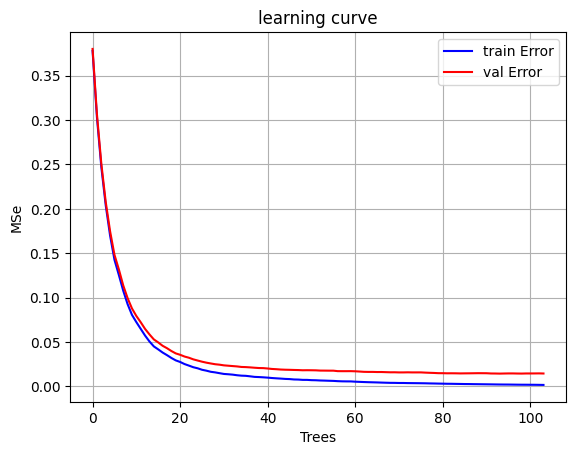

In [84]:
train_logloss = np.square(results['validation_0']['logloss'])
val_logloss = np.square(results['validation_1']['logloss'])


plt.plot(train_logloss, label='train Error', color='blue')
plt.plot(val_logloss, label='val Error', color='red')

plt.title('learning curve')
plt.xlabel('Trees')
plt.ylabel('MSe')
plt.legend()
plt.grid()
plt.show()

### 6.1 Model 2:  Tuned Logistic regression model result on the untouched test set

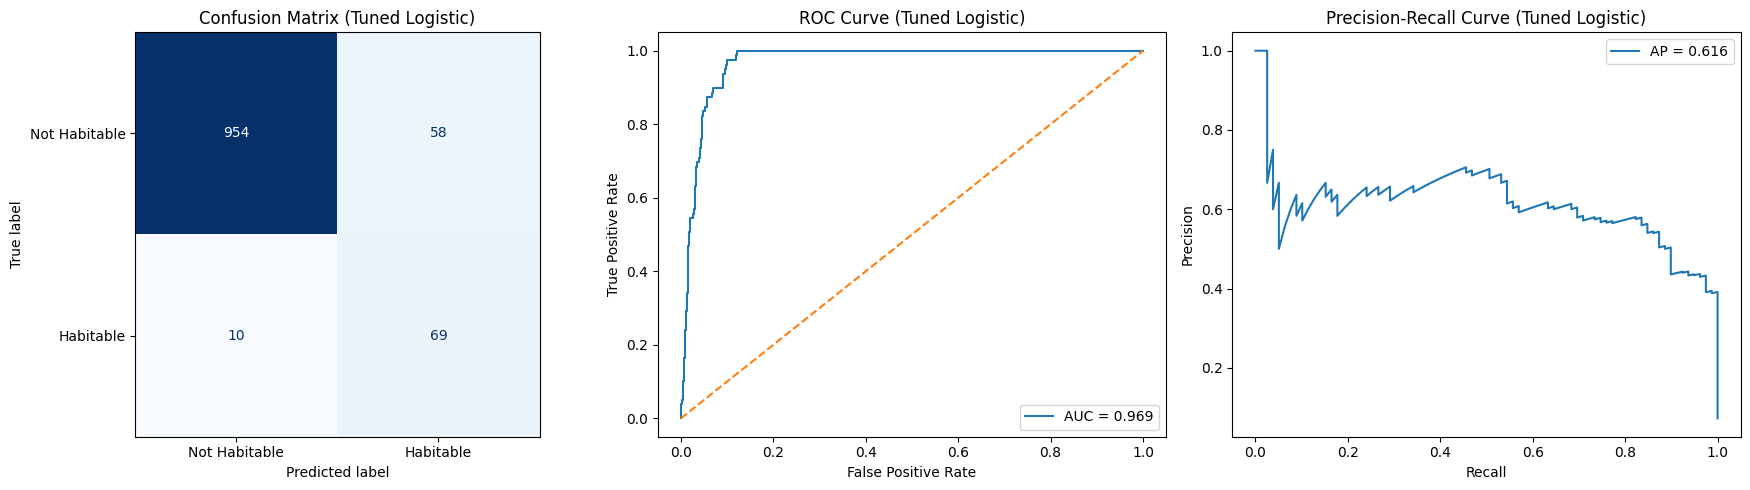

Tuned Logistic metrics at threshold = 0.500
threshold: 0.500
roc_auc: 0.9691
pr_auc: 0.6158
precision: 0.5433
recall: 0.8734
f1: 0.6699

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.97      1012
           1       0.54      0.87      0.67        79

    accuracy                           0.94      1091
   macro avg       0.77      0.91      0.82      1091
weighted avg       0.96      0.94      0.94      1091



In [85]:
tuned_metrics_05 = evaluate_probabilities(
    y_true=y_test,
    y_prob=test_prob_tuned,
    threshold=0.5,
    model_name="Tuned Logistic"
)

### 6.2 Threshold tuning on the validation set

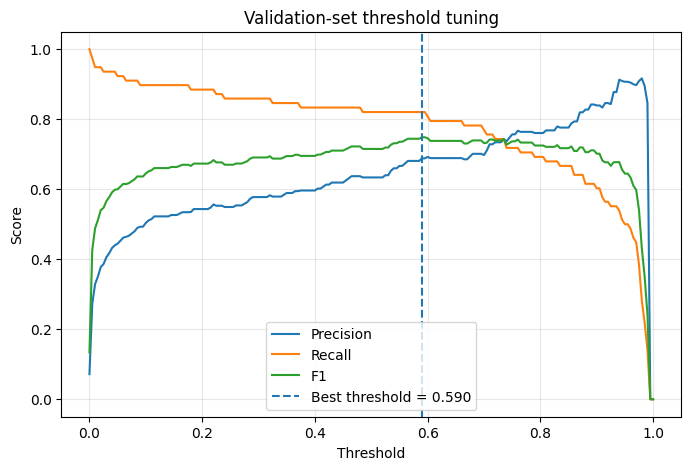

Best validation threshold: 0.59


,threshold,precision,recall,f1
119,0.595,0.688172,0.820513,0.748538
118,0.590,0.688172,0.820513,0.748538
120,0.600,0.692308,0.807692,0.745562
113,0.565,0.680851,0.820513,0.744186
117,0.585,0.680851,0.820513,0.744186


In [86]:
best_threshold, threshold_table = find_best_threshold(y_val, val_prob_tuned)
print("Best validation threshold:", round(best_threshold, 3))

threshold_table.sort_values("f1", ascending=False).head()

### 6.3 Model 3 : Tuned Logistic regression + Threshold tuning result on the untouched test set

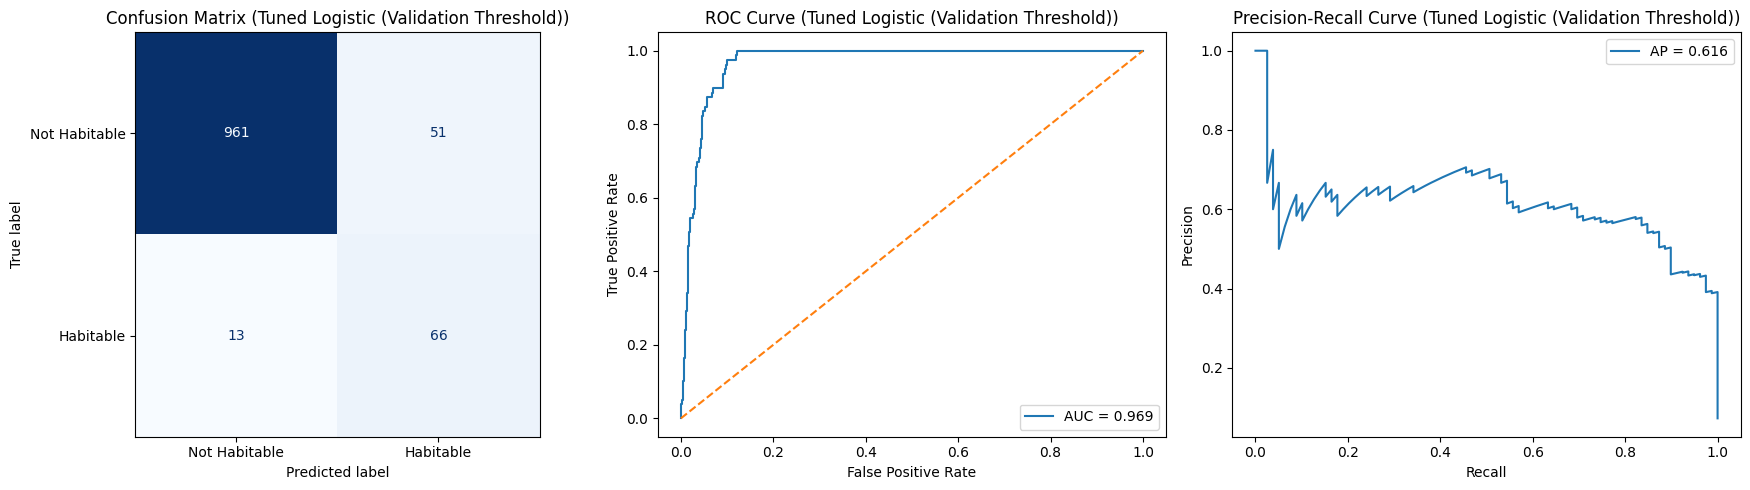

Tuned Logistic (Validation Threshold) metrics at threshold = 0.590
threshold: 0.590
roc_auc: 0.9691
pr_auc: 0.6158
precision: 0.5641
recall: 0.8354
f1: 0.6735

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1012
           1       0.56      0.84      0.67        79

    accuracy                           0.94      1091
   macro avg       0.78      0.89      0.82      1091
weighted avg       0.96      0.94      0.95      1091



In [87]:
tuned_metrics_opt = evaluate_probabilities(
    y_true=y_test,
    y_prob=test_prob_tuned,
    threshold=best_threshold,
    model_name="Tuned Logistic (Validation Threshold)"
)

## 7. feature importance and shapley values

In [88]:
best_lr = model.feature_importances_

coef_df = pd.DataFrame({
    "Feature": features,
    "feature importance": best_lr
}).sort_values("feature importance", ascending=False)

coef_df

,Feature,feature importance
9,log_stellar_flux,0.257716
11,log_star_temp,0.147055
1,orbital_period_days,0.097272
3,star_radius_sun,0.094646
4,star_mass_sun,0.093880
2,star_temp_k,0.084031
7,planet_radius_earth,0.062069
0,semi_major_axis_au,0.040629
12,temp_distance_interaction,0.030239
6,planet_mass_earth,0.027788


<Axes: xlabel='feature importance', ylabel='Feature'>

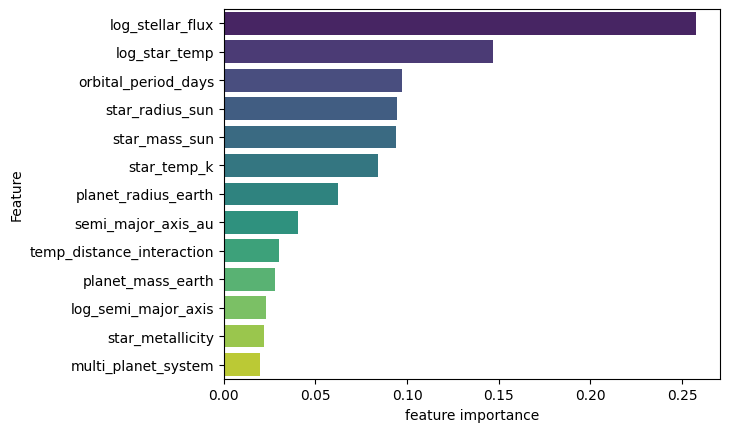

In [89]:
sns.barplot(data=coef_df, x="feature importance", y="Feature", palette="viridis")  

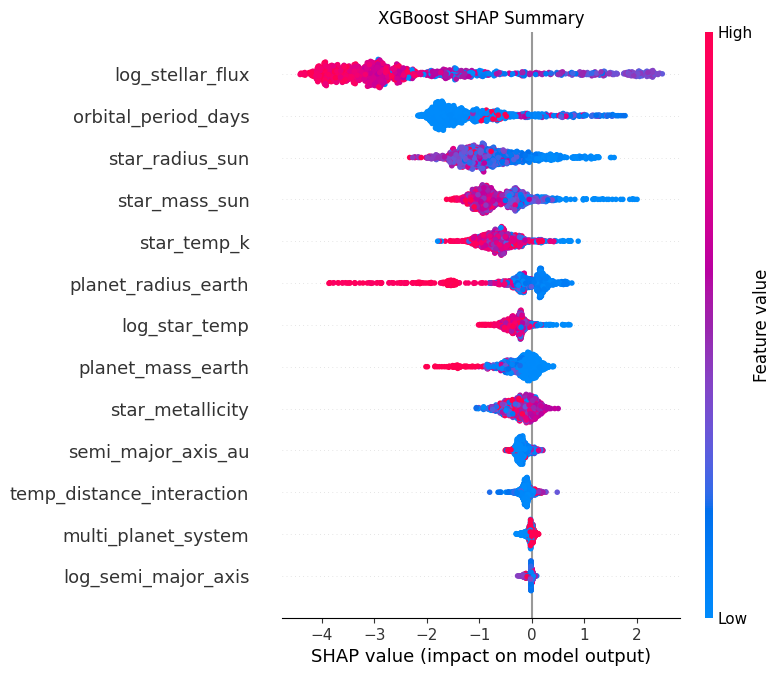

In [90]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)
shap.summary_plot(shap_values, X_val, show=False)
plt.title("XGBoost SHAP Summary")
plt.show()


### summary plot
Each dot is a single row. If a dot is to the right of the center line, that feature pushed the model toward predicting a 1 (If it’s to the left, it pushed it toward a 0). The color indicates if the value is high compared to mean (or median). Ex, if stellar flux is high, then the model is more confident in predicting 0.

### waterfall plot
explains one specific prediction (one single row) and shows exactly how the model arrived at its final probability.
-E(F(X)) is the average prediction (based on all predictions)
-f(X) is the final prediction for the specific row

Red Arrows (+): These features increased the probability for this specific instance.
Blue Arrows (-): These features decreased the probability.

Here, stellar_flux strongly pushed the probability down of predicting 1.

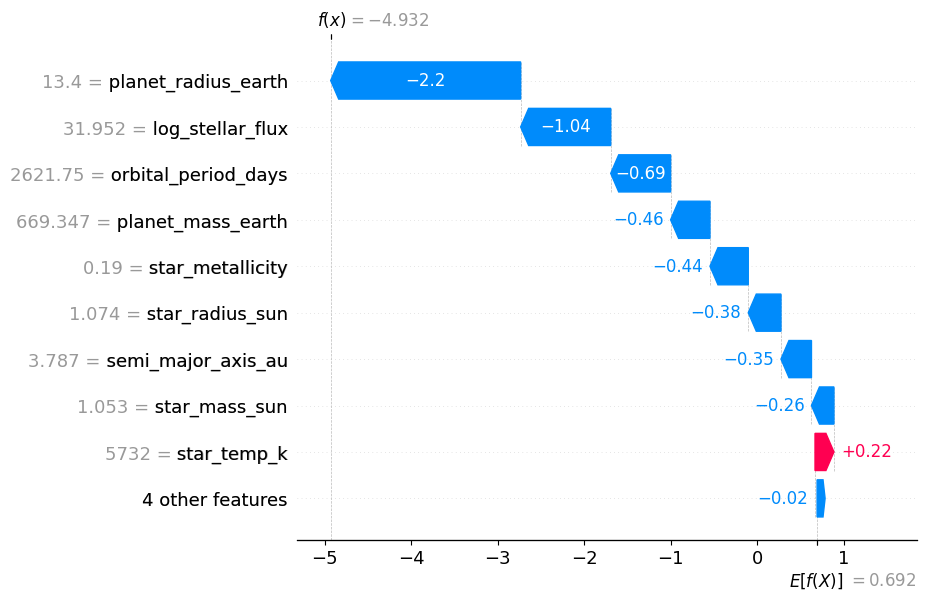

In [91]:
explanation = explainer(X_val)
shap.plots.waterfall(explanation[0])

In [92]:
print(type(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
(1090, 13)


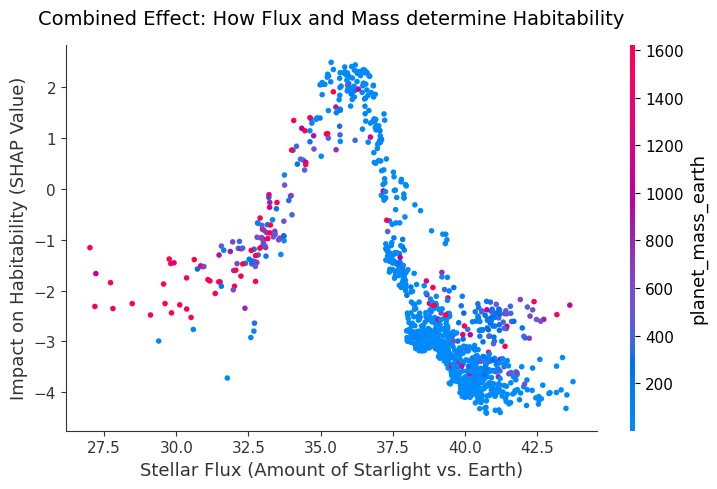

In [ ]:

if isinstance(shap_values, list):
    values_to_plot = shap_values[1]
elif hasattr(shap_values, "values"):
    if len(shap_values.values.shape) == 3:
        values_to_plot = shap_values.values[:, :, 1]
    else:
        values_to_plot = shap_values.values
else:
    if len(shap_values.shape) == 3:
        values_to_plot = shap_values[:, :, 1]
    else:
        values_to_plot = shap_values


shap.dependence_plot(
    "log_stellar_flux", 
    values_to_plot, 
    X_val, 
    interaction_index="planet_mass_earth",
    show=False 
)

ax = plt.gca()

ax.set_ylabel("Impact on Habitability (SHAP Value)")
ax.set_xlabel("Stellar Flux (Amount of Starlight vs. Earth)")

plt.title("Combined Effect: How Flux and Mass determine Habitability", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

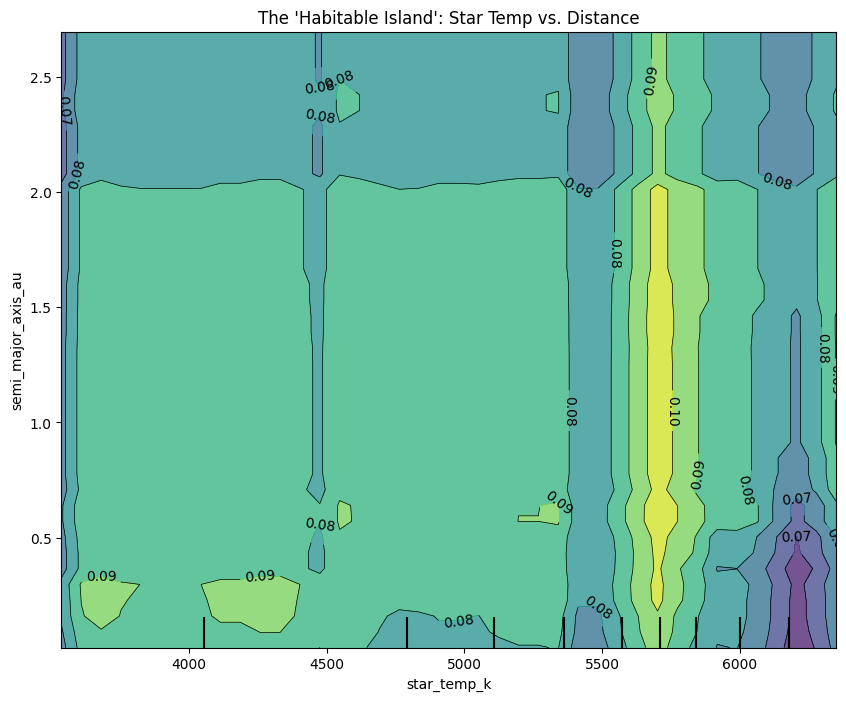

In [97]:
from sklearn.inspection import PartialDependenceDisplay

features = [('star_temp_k', 'semi_major_axis_au')]

fig, ax = plt.subplots(figsize=(10, 8))
PartialDependenceDisplay.from_estimator(
    model, 
    X_train, 
    features, 
    grid_resolution=40,
    ax=ax
)

plt.title("The 'Habitable Island': Star Temp vs. Distance")
plt.show()

# semi_major_axis_au : average distance from star, in astronomical units (AU)
# star_temp_k : star temperature in Kelvin , Blue start are hot, red dwarfs are cold

In [73]:
X_val.columns

Index(['semi_major_axis_au', 'orbital_period_days', 'star_temp_k',
       'star_radius_sun', 'star_mass_sun', 'star_metallicity',
       'planet_mass_earth', 'multi_planet_system', 'log_stellar_flux',
       'log_semi_major_axis', 'log_star_temp', 'temp_distance_interaction'],
      dtype='object')